# NODE / UDE - Remaining Useful Life (NASA C-MAPSS)

Este notebook implementa:

- Preprocesamiento de datos
- Construcción de RUL y probabilidad de falla
- NODE (Neural ODE)
- UDE (Universal Differential Equation)

In [1]:
using Pkg
Pkg.activate(".")



#solo la primera vez:
#Pkg.instantiate()

  Activating project at `c:\Users\Sebastian\Desktop\TP-DegradacionDeMotores\mi_entorno`


## Todas los paquetes que utilizaremos.

In [2]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Statistics
using Plots

using Lux
using ComponentArrays
using Random
Random.seed!(42)

using OrdinaryDiffEq
using SciMLSensitivity

using Optimization
using OptimizationOptimisers
using Zygote

## Carga de datos

In [3]:
dataset_path = joinpath(pwd(), "..", "CMaps", "train_FD001.txt")

train_df = CSV.read(
    dataset_path,
    DataFrame;
    delim=' ',
    ignorerepeated=true,
    header=false
)


#agregamos los nombres de la columnas ya que el dataset original venian sin ellos
rename!(
    train_df,
    vcat(
        ["unit", "cycle", "setting1", "setting2", "setting3"],
        ["s$i" for i in 1:21]
    )
)

first(train_df, 5)

Row,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64
1,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
2,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
3,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
4,1,4,0.0007,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
5,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


## Normalización de sensores y settings

In [4]:
#Normalizamos los datos de los sensores y settings para mejorar entrenamiento de redes neuronales.


sensor_cols = ["s$i" for i in 1:21]
setting_cols = ["setting1", "setting2", "setting3"]
    
for col in sensor_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end
    
for col in setting_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end

## Construcción de RUL y probabilidad de falla.

In [5]:
#Construimos el cilo de falla. En el train la falla se da en el último ciclo observado.
fail_cycles = combine(
    groupby(train_df, :unit),
    :cycle => maximum => :T_fail
)

#Obtenemos un df de la siguiente forma:
#unit    T_fail
#1       192

#Ahora mergeamos con el dataset original
train_df = leftjoin(train_df, fail_cycles, on=:unit)

#Ahora empezamos a construir la proba de falla en cada ciclo.
train_df.RUL = train_df.T_fail .- train_df.cycle

#Para construir la proba vamos a utilizar un funcion sigmoide, que sea baja           lejos de la falla y aumenta rapido cerca de la falla.
      
σ(x) = 1 / (1 + exp(-x))


#Estos hiperparametros habria que chequearlos bien...
k = 0.08
threshold = 40
    
train_df.p_fail = σ.(k .* (threshold .- train_df.RUL))

20631-element Vector{Float64}:
 5.671790689635885e-6
 6.144174602214718e-6
 6.6559014820897696e-6
 7.2102480022617275e-6
 7.810763725056275e-6
 8.461293827645233e-6
 9.16600371985333e-6
 9.929405711774312e-6
 1.0756387901826074e-5
 1.165224547006964e-5
 1.2622714576991388e-5
 1.3674009084599712e-5
 1.4812860334722366e-5
 ⋮
 0.9105199406664386
 0.9168273035060777
 0.9227277978633401
 0.9282424577362486
 0.9333919644249093
 0.9381965337364114
 0.9426758241011313
 0.9468488636019362
 0.9507339939159732
 0.9543488292155562
 0.9577102281579662
 0.9608342772032357

## Ejemplo de curva de falla

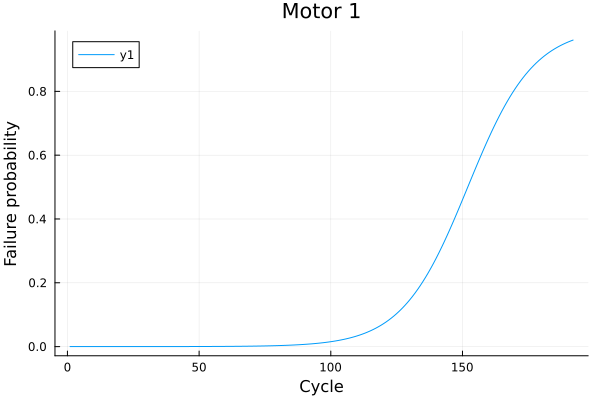

In [6]:
motor1 = filter(row -> row.unit == 1, train_df)
    
plt = plot(
    motor1.cycle,
    motor1.p_fail,
    xlabel="Cycle",
    ylabel="Failure probability",
    title="Motor 1"
)
    
plt

##  Trayectorias por motor

In [7]:
#agrupamos por unidad
grouped = groupby(train_df, :unit)
    
trajectories = []
    
for g in grouped
    X = Matrix(g[:, vcat(setting_cols, sensor_cols)])
    y = g.p_fail
    t = g.cycle
    
    push!(trajectories, (X=X, y=y, t=t))
end

##  NODE: dp/dt = NN(p, t)

NODE simple donde solo usamos los ciclos. Todavia no incorporamos sensores.

In [8]:
#elegimos una trayectoria
traj = trajectories[1]

print(trajectories)

t = Float64.(traj.t)
y = Float64.(traj.y)
    
u0 = [y[1]]
    
#generador de numeros aleatorios, sirve para inicializar los pesos de la red
rng = Random.default_rng()

#estructura de la red
nn = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#p: parametros entrenables de la red, st: estados internos
p_node, st_node = Lux.setup(rng, nn)
#esto es para que funcione bien la optimizacion
p_node = ComponentArray(p_node)

Any[(X = [-0.31597202195452145 -1.3729199290729734 NaN 0.9999757643323645 -1.7216836648226865 -0.13425192213570927 -0.925913523696359 -0.9999757643323643 0.14167989491882235 1.1211133982073023 -0.516325892386186 -0.8627924043441415 0.9999757643323643 -0.2664601377187745 0.33425373913469153 -1.0588645739680291 -0.26906451920303553 -0.603801065881639 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.3484600620382499 1.1943981001535333; 0.8727007771683792 -1.0316953503320596 NaN 0.9999757643323645 -1.0617539738121262 0.2115233673416215 -0.6437102649230355 -0.9999757643323643 0.14167989491882235 0.4319197071333588 -0.7980736570341316 -0.9587943771663178 0.9999757643323643 -0.1915782821843463 1.174870847738156 -0.3636371846989997 -0.6428291567796645 -0.27584512524895916 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.0165032941737064 1.2368919830975704; -1.9618266668939224 1.015652122113423 NaN 0.9999757643323645 -0.6617965853206986 -0.4131555754405577 -0.5259404010255218 -0.9999757643323

Excessive output truncated after 524288 bytes.

 0.46983714374818336 1.3049085495390833 -1.1135733987765666 -0.2865103590906935 -0.9999757643323645 -0.13601426883344866 NaN NaN 0.9058510382188456 -0.38988470960789146; -1.4589266364957725 1.015652122113423 NaN 0.9999757643323645 0.3980904941812893 -0.4294657306045688 0.2173429852710957 -0.9999757643323643 0.14167989491882235 0.38672667821051937 0.6106651662055962 -1.2314037528216595 0.9999757643323643 0.03306728441888523 -0.7097384763889336 1.0268175938327362 -1.2477722027311677 -0.5318107374500624 -0.9999757643323645 0.5096623027963773 NaN NaN 0.020632990580115574 -0.019448903943539344; -0.4531265756994716 0.6744275433725094 NaN 0.9999757643323645 -0.4218221522258874 0.10387634325907445 0.07068617362510934 -0.9999757643323643 0.14167989491882235 -0.3250635273248439 0.4697912838848265 -0.7686017894997811 0.9999757643323643 0.10794913995331347 -0.19452153885778792 0.6096811602700539 -1.405036426115441 -0.8357699019388517 -0.9999757643323645 0.5096623027963773 NaN NaN 0.463242014399480

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.18582273 0.073365726; -1.3326262 1.9626849; … ; -1.2206342 0.22496898; 1.2360227 0.50070494], bias = Float32[0.45274794, -0.109943174, 0.2535509, 0.33633876, -0.58940434, -0.5645052, -0.6811371, -0.25305128, 0.11489113, 0.6639945, -0.4025346, -0.6888659, -0.4826754, 0.3613354, 0.48929778, -0.21674016]), layer_2 = (weight = Float32[0.3199716 0.046035804 … 0.03958083 -0.19888853], bias = Float32[-0.0893096]))

Definimos la NODE

In [9]:
function node!(du, u, p, t)
    input = [u[1], t]

    du .= nn(input, p, st_node)[1]
end

node! (generic function with 1 method)

In [10]:
#todo el intervalo de tiempo
tspan = (t[1], t[end])
	
#definimos el problema de ode
prob_node = ODEProblem(node!, u0, tspan, p_node)
	
#resolvemos con solver numerico
sol = solve(prob_node, Tsit5(), saveat=t)

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Matrix{Float64}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl C:\Users\Sebastian\.julia\packages\LuxLib\zPBrt\src\impl\matmul.jl:194


retcode: Success
Interpolation: 1st order linear
t: 192-element Vector{Float64}:
   1.0
   2.0
   3.0
   4.0
   5.0
   6.0
   7.0
   8.0
   9.0
  10.0
  11.0
  12.0
  13.0
   ⋮
 181.0
 182.0
 183.0
 184.0
 185.0
 186.0
 187.0
 188.0
 189.0
 190.0
 191.0
 192.0
u: 192-element Vector{Vector{Float64}}:
 [5.671790689635885e-6]
 [-0.6389859493328393]
 [-1.1971182814602073]
 [-1.690072756169595]
 [-2.1514591085398314]
 [-2.5924914293618455]
 [-3.0142288955066787]
 [-3.41512428090587]
 [-3.7941918771853764]
 [-4.152477724694881]
 [-4.4935622499326975]
 [-4.822654969579479]
 [-5.145814746895945]
 ⋮
 [-72.39173281608667]
 [-72.79671447659534]
 [-73.20170800458831]
 [-73.60671244711838]
 [-74.01172685927285]
 [-74.41675030417355]
 [-74.82178185297677]
 [-75.22682058487337]
 [-75.63186558708865]
 [-76.03691595488252]
 [-76.44197079154928]
 [-76.84702920841788]

## Predicción sin entrenamiento

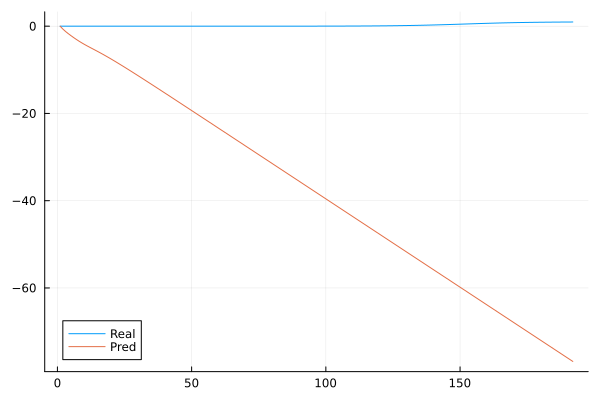

In [11]:
plt2 = plot(t, y, label="Real")
plot!(plt2, t, vec(Array(sol)), label="Pred")
	
plt2

Como se puede observar, al no haber entrenado la red no obtenemos buenos resultados.

##  Entrenamiento NODE

In [12]:
#funcion de prediccion
function predict(prob, p, t)

    _prob = remake(prob, p=p)
    
    sol = solve(
        _prob,
        Tsit5(),
        saveat=t
    )
    
    Array(sol)[1, :]
end

#funcion de perdida basica
function loss(prob, p, t, y)

    pred = predict(prob, p, t)
    
    sum(abs2, pred .- y)

end

loss (generic function with 1 method)

In [13]:
#convertimos la funcion loss en algo digerible por el optimizador. Con AutoZygote() calculamos los gradientes.
optf_node = OptimizationFunction((x, _) -> loss(prob_node,x,t,y), AutoZygote())

#Define el problema de opt. Quiero minimizar optf empezando de parametros iniciales p.
optprob_node = OptimizationProblem(optf_node, p_node)

#Resulve el problema de opt. Con Adam version de descenso por el gradiente y 0.01 el learning rate.
result_node = Optimization.solve(optprob_node, Adam(0.01), maxiters=500)
	
p_trained_node = result_node.u

#prediccion final luego de entrenar:
pred_node = predict(prob_node, p_trained_node, t)

192-element Vector{Float64}:
  5.671790689635885e-6
 -0.04486189459213208
 -0.09923701153516558
 -0.10557307590261993
 -0.08825253220874044
 -0.06583979844147159
 -0.0454655777956574
 -0.028559856620187892
 -0.01470540925328058
 -0.003102457060216534
  0.006904103000575
  0.01578480792529694
  0.023850731578054535
  ⋮
  0.5060307930153963
  0.5087826946345434
  0.511393606125688
  0.5138622514178848
  0.5163580730718544
  0.5190931110050987
  0.5218390301951028
  0.5244324199162117
  0.5268896469724834
  0.5294020026491865
  0.5320855595302143
  0.5347326611146708

Graficamos la sol obtenida

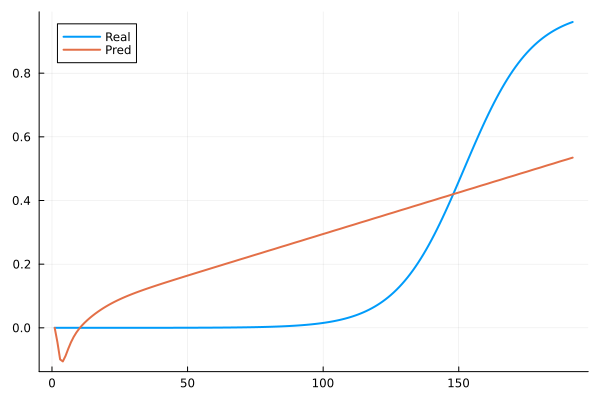

In [14]:
p1 = plot(
        t,
        y,
        label="Real",
        linewidth=2
    )
    
plot!(
    p1,
    t,
    pred_node,
    label="Pred",
    linewidth=2
)

p1

##  UDE: término físico + red neuronal

dp/dt = -αu + NN(p,t) 

In [15]:
#Definimos la red
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#parametros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)
    
α = 0.05

#definimos ude
function ude!(du, u, p, t)

    input = [u[1], t]
    du .= .-α .* u .+ nn2(input, p, st_ude)[1]

end

#definimos problema ode
prob_ude = ODEProblem(ude!, u0, tspan, p_ude)

#mismo proceso de antes
optf_ude = OptimizationFunction(
(x, _) -> loss(prob_ude,x,t,y),
AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u
pred_ude = predict(prob_ude, p_trained_ude, t)

192-element Vector{Float64}:
 5.671790689635885e-6
 0.01001693725453021
 0.014888588404793629
 0.013339684623135459
 0.012646724397608477
 0.013027048314762727
 0.01347481030924492
 0.013476376014399306
 0.013004675309415023
 0.012242592109516165
 0.011405869610272448
 0.0106559358681227
 0.010087002132088553
 ⋮
 0.7409687130380658
 0.7488095664867602
 0.7566395614146898
 0.7644591908841722
 0.7722616118269156
 0.7800457338504894
 0.787811210780998
 0.7955577844637031
 0.8032852847630239
 0.8109936295625374
 0.818682824764978
 0.8263529642922387

Graficamos la sol obtenida:

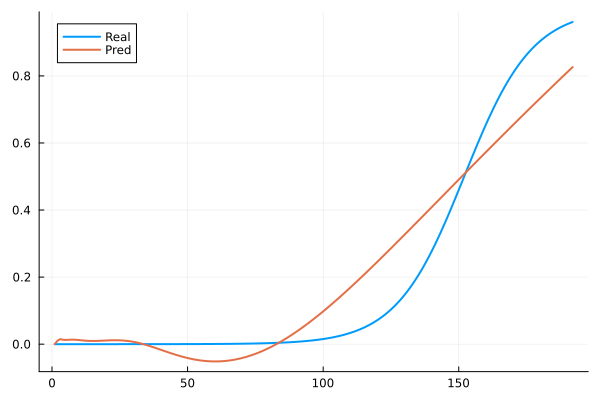

In [16]:
p2 = plot(
    t,
    y,
    label="Real",
    linewidth=2
    )
    
plot!(
    p2,
    t,
    pred_ude,
    label="Pred",
    linewidth=2
)

##  UDE: término físico + red neuronal agregando motores


In [17]:
#Ahora tengamos en cuenta mas de una trayectoria de motor.

#hago una funcion para no practicar con todas las trajs a la ves, si no tarda demasiado

n_motors = length(trajectories)


function build_train_trajs(trajectories; n_motors=nothing, shuffle=false, seed=1234)

    total_motors = length(trajectories)

    if n_motors === nothing
        selected_ids = collect(1:total_motors)
    else
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = collect(1:n)
    end


    #esto recontraponele, capaz sirve capaz no, pero como el test te da cualquier motor esto lo hace mas random
    if shuffle
        rng = Random.default_rng()
        Random.seed!(rng, seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    train_trajs = [
        (
            X = trajectories[i].X,
            t = Float64.(trajectories[i].t),
            y = Float64.(trajectories[i].y)
        )
        for i in selected_ids
    ]

    return train_trajs
end

function predict_traj(f!, p, traj)

    t = traj.t
    y = traj.y

    u0 = [y[1]]
    tspan = (t[1], t[end])

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=t,
        abstol=1e-6,
        reltol=1e-6
    )

    return Array(sol)[1, :]
end

function loss_many(f!, p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj(f!, p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points
end

loss_many (generic function with 1 method)

La función de pérdida total sobre varios motores se define como:

$$
\mathcal{L}(\theta)
=
\frac{1}{\sum_{i=1}^{M} T_i}
\sum_{i=1}^{M}
\sum_{j=1}^{T_i}
\left(
\hat{y}_{i,j}(\theta) - y_{i,j}
\right)^2
$$

In [18]:
#para las pruebas vamos con 10.



# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05




0.05

In [19]:
train_trajs = build_train_trajs(trajectories, n_motors=10)

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u

usando 10 de 100 motores


ComponentVector{Float32}(layer_1 = (weight = Float32[-1.4433072 1.5040276; -1.1167465 1.4992776; … ; 0.711315 -0.18016283; 1.1846573 -0.79772323], bias = Float32[0.26171827, 0.61702967, -0.7174178, 0.42428952, -0.019187458, -0.7265475, 0.58127385, -0.44156283, 0.10616454, -0.2125361, 0.65605277, -0.04891494, -0.23613827, -0.13894254, -0.45984954, -0.67627084]), layer_2 = (weight = Float32[-0.03210224 -0.031218512 … 0.16428986 -0.1392004], bias = Float32[0.10490558]))

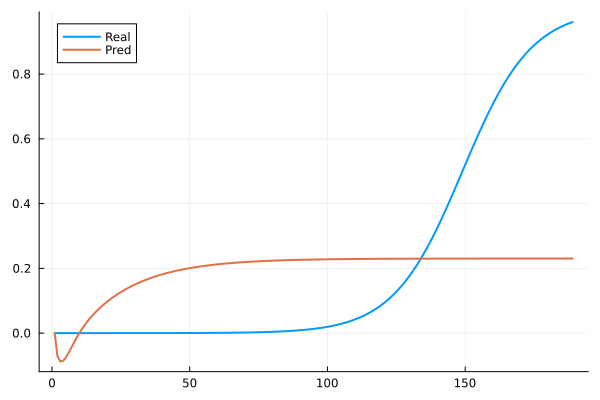

In [20]:
traj_plot = train_trajs[4]

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_n,
    label="Pred",
    linewidth=2
)

Empeora bastante... Esto puede ser ya que estoy intentando generalizar para todos los motores, sin tener cuenta los sensores. entonces, cuando veo para el caso particular 1, no calcula bien.

Si aumento cnt de motores a 30:


usando 30 de 100 motores


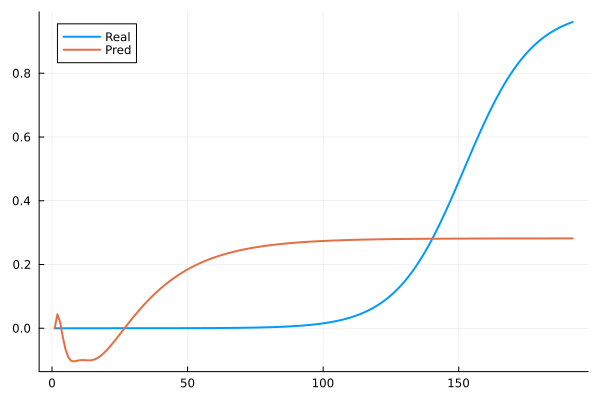

In [21]:


# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05


train_trajs = build_train_trajs(trajectories, n_motors=30)

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u

traj_plot = train_trajs[1]

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_n,
    label="Pred",
    linewidth=2
)

##  UDE: término físico + red neuronal + sensores para 1 (un) motor (no sabes lo q tarda en correr con 10)

dp/dt = -αu + NN(p,t,sens) 

In [22]:
using DataInterpolations


In [23]:
function build_train_trajs_sensors(trajectories; n_motors=nothing, shuffle=false,sensors=nothing, seed=67)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    # default: usar todos los sensores
    if sensors === nothing
        sensors = 4:size(trajectories[1].X, 2)
    end

    train_trajs = []

    for i in selected_ids

        t = Float64.(trajectories[i].t)

        S = Float64.(trajectories[i].X[:, sensors])

        # un interpolador por sensor, para que no quede todo discreto y de a saltos.
        sensor_interps = [
            LinearInterpolation(S[:, j], t)
            for j in 1:size(S,2)
        ]
        #esto termina siendo como funciones para cada sensor: s_1(t), s_2(t), ....

        push!(train_trajs,
            (
                sensor_interps = sensor_interps,
                sensors_ids = sensors,                  #para no perder los sensores que utilizamos
                t = t,
                y = Float64.(trajectories[i].y)
            )
        )
    end

    return train_trajs
end

build_train_trajs_sensors (generic function with 1 method)

In [24]:
train_trajs_sensors = build_train_trajs_sensors(
    trajectories;
    n_motors=1,
    sensors = [6,7]
)
n_sensors = length(train_trajs_sensors[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2 = Lux.Chain(
    Lux.Dense(input_dim, 8, tanh), #aumente entrada para incluir sensores
    Lux.Dense(8, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)

α = 0.05


function ude_sensors!(du, u, p, τ, S)

    input = [u[1]; τ; S] #esto antes estaba en Float32, pero eso rompía las cosas

    out, _ = nn2(input, p, st_ude_sensors)

    du[1] = -α * u[1] + out[1]

end


function predict_traj_sensors(p, traj)

    tvec = traj.t
    y = traj.y
    

    u0 = [y[1]]

    t0 = tvec[1]
    tf = tvec[end]
    tspan = (t0, tf)

    function f!(du, u, p, t)

        #idx = clamp(searchsortedlast(tvec, t), 1, length(tvec)) #a ver, esto es para encontrar el indice del tiempo actual en el vector de tiempos de la trayectoria porque la red usa ts intermedios (t=0.5 ponele) y ahi
                                        #no hay sensores. Entonces buscamos el indice del tiempo mas cercano que no sea mayor a t, y usamos los sensores de ese indice. es una aprox, hay q charlarlo

        
        
        #S = vec(S_traj[idx, :])

        #dejo comentado lo que estaba antes y pruebo los interpoladores

        S = [
            interp(clamp(t, t0, tf))
            for interp in traj.sensor_interps
        ]

        τ = (t - t0) / (tf - t0)

        ude_sensors!(du, u, p, τ, S)

    end

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax = 1.0
    )

    return Array(sol)[1, :]

end

usando 1 de 100 motores
Cantidad de sensores usados: 2


predict_traj_sensors (generic function with 1 method)

In [25]:
function loss_many_sensors(p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj_sensors(p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points

end

loss_many_sensors (generic function with 1 method)

In [26]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)

result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3), #baje el learning rate, para que no se vuelva loco el optimizador
    maxiters=500, 
    callback = (state, loss) -> begin
        println(loss)
        false
    end
)

p_trained_ude_sensors = result_ude_sensors.u

1.4369390320452264
1.3824336404994833
1.3302565828967456
1.2805056813538633
1.2328562497558242
1.1873451560247443
1.143980908111461
1.10248991280314
1.0629710547046738
1.0253140135918375
0.9893440842094355
0.9550405214037506
0.9223047426820009
0.8911300437304877
0.8613413685845227
0.832947117195089
0.8058302246283894
0.7799236465430123
0.755243804867287
0.7315704868538612
0.7089565267839911
0.6873335219437928
0.6666390945428129
0.6468343164408968
0.6279110379965959
0.6097106647820169
0.5923439387722554
0.5756897744869564
0.5597180172457207
0.5444297489430842
0.5297964381319914
0.5157287142882515
0.5022553591091059
0.48934896743052425
0.4769483830427359
0.4650680197388202
0.4536746396181863
0.4427768265711592
0.43234118427196006
0.4222774039371331
0.4126725791388714
0.40342825010211075
0.3945592656091977
0.3860593135030221
0.37790475995921025
0.37007625730809085
0.36256655759435913
0.35537239590017106
0.3484309810790458
0.3418224691089939
0.33546710684814246
0.3292935006289875
0.3234093

ComponentVector{Float32}(layer_1 = (weight = Float32[-1.2298175 -0.5732174 0.8782784 -1.1226822; -1.5356649 0.30144408 0.0528993 -1.1320233; … ; -0.35019282 -1.4870645 -0.34794876 -1.074513; 0.37509575 -0.63595814 0.25346017 0.95444715], bias = Float32[0.3821464, -0.3706691, -0.14114247, -0.6799119, 0.14511918, 0.5758145, -0.0762682, 0.22622406]), layer_2 = (weight = Float32[0.5818216 0.101497486 … -0.34725618 -0.35311374], bias = Float32[0.08420571]))

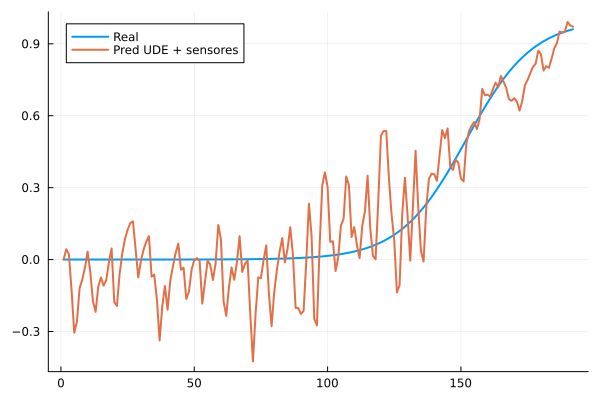

In [27]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

## Resumen hasta acá...

Realizamos los siguientes experimentos:

+ Modelamos el problema como una NODE, solo utilizando el estado actual y el tiempo
+ Modelamos con una UDE, pero seguimos sin usar sensores
+ Entrenamos la UDE con más de una trayectoria
+ Incorporamos los sensores al modelo

Pero en el último paso nos encontramos con un problema....

Si agregamos todos los sensores al modelo nos termina quedando algo muy complejo que tarda muchísimo en correr. Entonces planteamos el siguente paso:

**Vamos a estudiar los sensores y decidir cuales son los más influyentes en el estudio de la dinámica de probabilidad de falla**

## Selección de sensores

### 1. Estudiamos varianza de los sensores

In [28]:
variances = DataFrame(
    sensor = sensor_cols,
    variance = [
        var(train_df[!, col])
        for col in sensor_cols
    ]
)

sort!(variances, :variance, rev=true)

variances

Row,sensor,variance
,String,Float64
1,s18,NaN
2,s19,NaN
3,s6,1.0
4,s2,1.0
5,s17,1.0
6,s4,1.0
7,s8,1.0
8,s9,1.0
9,s11,1.0


Recordemos que al principio del trabajo normalizamos los datos de los sensores utilizando la transformación:

$$
\frac{x - \mu}{\sigma}
$$

Por lo tanto, observamos que:

- Dos sensores presentan $Var = NaN$. Esto ocurre debido a que $\sigma = 0$, es decir, el sensor toma un valor constante para todo instante de tiempo y, por lo tanto, no aporta información útil al modelo.

- Cuatro sensores presentan una varianza muy pequeña. En consecuencia, son sensores casi constantes y decidimos excluirlos del análisis.

- Los sensores restantes presentan $Var = 1$, lo cual es esperable luego del proceso de normalización. Estos sensores son los que superan el primer filtro de selección.

In [29]:
#Definimos los sensores válidos hasta el momento:

valid_sensors = []

for col in sensor_cols

    σ_col = std(train_df[!, col])

    if !isnan(σ_col) && σ_col > 1e-8
        push!(valid_sensors, col)
    end
end

println(valid_sensors)

Any["s2", "s3", "s4", "s6", "s7", "s8", "s9", "s11", "s12", "s13", "s14", "s15", "s17", "s20", "s21"]


### 2. Correlación con RUL

La idea es identificar sensores cuyo comportamiento esté fuertemente asociado al proceso de degradación del motor.

Utilizamos el coeficiente de correlación de Pearson:

$$
\rho_{X,Y} = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}
$$

Valores cercanos a:

- $1$ indican correlación positiva fuerte
- $-1$ indican correlación negativa fuerte
- $0$ indican ausencia de correlación lineal

In [30]:
correlations = DataFrame(
    sensor = valid_sensors,
    correlation = [
        cor(train_df[!, col], train_df.RUL)
        for col in valid_sensors
    ]
)

correlations.abs_corr = abs.(correlations.correlation)

sort!(correlations, :abs_corr, rev=true)

correlations

Row,sensor,correlation,abs_corr
,Any,Float64,Float64
1,s11,-0.696228,0.696228
2,s4,-0.678948,0.678948
3,s12,0.671983,0.671983
4,s7,0.657223,0.657223
5,s15,-0.642667,0.642667
6,s21,0.635662,0.635662
7,s20,0.629428,0.629428
8,s2,-0.606484,0.606484
9,s17,-0.606154,0.606154


Nos quedaremos con el top 5 de los más correlacionados (veremos si es top 5 o menos... todo depende de cuanto tarde)

In [31]:
selected_sensors = correlations.sensor[1:5]

#y obtenemos los indices que es lo que nos sirve para pasarle a la funcion que utilizamos
sensor_indices = [
    findfirst(==(s), names(train_df))
    for s in selected_sensors
]

5-element Vector{Int64}:
 16
  9
 17
 12
 20

Ahora veamos como evolucionan algunos de los sensores elegidos comparados con la probabilidad de falla:

In [32]:
function plot_sensor_vs_pfail(sensor_name; unit_id=1)

    motor = filter(row -> row.unit == unit_id, train_df)

    p = plot(
        motor.cycle,
        motor[!, sensor_name],
        xlabel="Cycle",
        ylabel=sensor_name,
        label=sensor_name,
        linewidth=2
    )

    plot!(
        p,
        motor.cycle,
        motor.p_fail,
        ylabel="p_fail",
        label="p_fail",
        linewidth=2,
        yaxis=:right
    )

    return p
end


plot_sensor_vs_pfail (generic function with 1 method)

┌ Warning: Skipped yaxis arg right
└ @ Plots C:\Users\Sebastian\.julia\packages\Plots\GIume\src\axes.jl:75


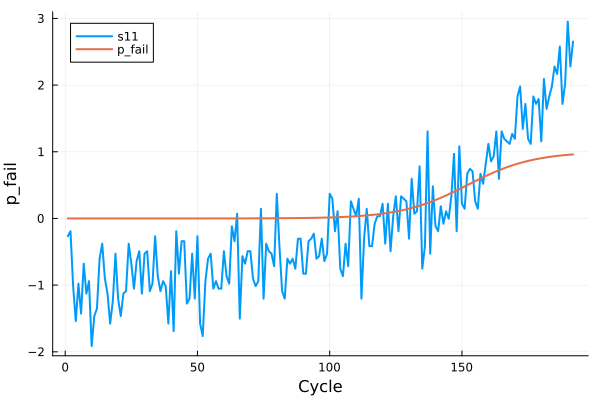

┌ Warning: Skipped yaxis arg right
└ @ Plots C:\Users\Sebastian\.julia\packages\Plots\GIume\src\axes.jl:75


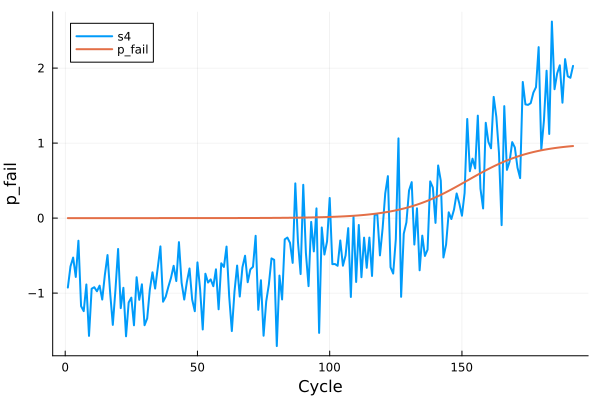

In [33]:
display(plot_sensor_vs_pfail("s11"))
display(plot_sensor_vs_pfail("s4"))

Luego de esto damos por finalizada la selección de sensores!

## UDE de antes usando los mejores sensores

En las primeras versiones del modelo utilizamos una dinámica sencilla de la forma:

$$
\frac{dp}{dt} = -\alpha p + NN(p,\tau,S(t))
$$

donde:

- $p(t)$ representa la probabilidad de falla,
- $\alpha p$ corresponde a un término físico simple,
- y $NN(\cdot)$ modela efectos no lineales aprendidos a partir de los datos.

Vamos a poner a prueba este modelo nuevamente. Pero esta vez utilizaremos los mejores sensores.

In [34]:
train_trajs_sensors = build_train_trajs_sensors(
    trajectories;
    n_motors=1,
    sensors = sensor_indices
)
n_sensors = length(train_trajs_sensors[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2 = Lux.Chain(
    Lux.Dense(input_dim, 8, tanh), 
    Lux.Dense(8, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)


usando 1 de 100 motores
Cantidad de sensores usados: 5


ComponentVector{Float32}(layer_1 = (weight = Float32[-0.07255504 1.0328946 … -0.87231374 -0.50457275; -0.8853711 -0.26409265 … -0.08173108 0.8887907; … ; 0.327073 -1.0302397 … -0.91170895 0.44349438; 0.14375076 0.5680567 … 0.114604466 -0.72184145], bias = Float32[0.22577596, 0.19985121, -0.0051052594, -0.15510212, 0.2739814, 0.32782844, 0.06507353, -0.22103818]), layer_2 = (weight = Float32[0.50426877 0.498187 … -0.44560358 -0.48255286], bias = Float32[0.12746628]))

In [35]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)


#agregamos early stopping...
best_loss = Inf
best_params = nothing

patience = 30
counter = 0

callback = function (state, loss)

    println(loss)

    if loss < best_loss - 1e-6

        global best_loss = loss
        global best_params = deepcopy(state.u)

        global counter = 0

    else

        global counter += 1

    end

    if counter >= patience

        println("Early stopping activado")

        return true
    end

    return false
end


result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000,
    callback=callback
)

p_trained_ude_sensors = best_params

0.10070709157069875
0.09500428136472742
0.08982818199936261
0.08517013882766693
0.08099914781015106
0.07728021634784539
0.07396869809366974
0.07103765598626761
0.06842228998787284
0.06610218050395349
0.06401450945233432
0.06211451001386748
0.06035267547499976
0.058706663704956426
0.05713975369420287
0.05563681997092489
0.05418649333408176
0.05278728176876658
0.05144646232474142
0.0501592838416239
0.048932119291618885
0.04777678078177513
0.04668969594474704
0.04567656483425553
0.04474375796986144
0.0438814517567812
0.04309044623194674
0.04235392488721242
0.04168204695971418
0.04105463142620886
0.040461571645949296
0.0399050688441106
0.03936950842646644
0.03885079169871282
0.03833453760579107
0.037832473325177744
0.03733476158237518
0.03683825572829087
0.03635132357267252
0.03586049914063404
0.03537541124970906
0.03489593617825654
0.03442552807783625
0.03395423203174536
0.033492449309857376
0.033033438615074316
0.03258096046251269
0.03213741038546985
0.03169307913911595
0.031254690928703

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.02172758 1.0438999 … -0.89270276 -0.45281407; -0.6268027 -0.14108983 … -0.34344292 0.8686809; … ; 0.16460453 -1.101137 … -0.7022149 0.42595202; 0.20772195 0.59423465 … 0.14071102 -0.7125667], bias = Float32[0.17360961, 0.237875, 0.122333325, -0.29985222, 0.39998242, 0.61233646, 0.1968305, -0.046421424]), layer_2 = (weight = Float32[0.41262275 0.38022932 … -0.48092 -0.2772219], bias = Float32[0.03843183]))

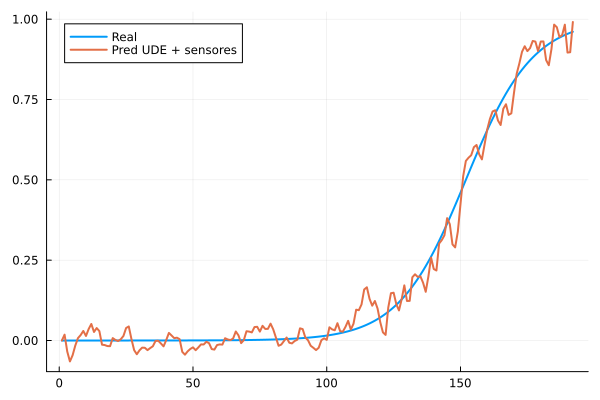

In [36]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

Como se puede ver obtenemos un resultado muy ruidoso.

## Regularización

Para dejar atrás los resultados ruidosos vamos a agregar términos de regularización a nuestra función de pérdida.

In [41]:
function loss_many_sensors_reg(p, trajs)

    total_loss = 0.0
    total_points = 0

    λ = 1e-6   # peso de regularización

    for traj in trajs

        pred = predict_traj_sensors(p, traj)
        y = traj.y

        # loss de ajuste
        data_loss = sum(abs2, pred .- y)

        # regularización de suavidad
        smoothness_loss = sum(abs2, diff(pred))

        total_loss += data_loss + λ * smoothness_loss

        total_points += length(y)

    end

    return total_loss / total_points

end

loss_many_sensors_reg (generic function with 1 method)

y repetimos lo de antes...

In [42]:
nn2 = Lux.Chain(
    Lux.Dense(input_dim, 8, tanh), 
    Lux.Dense(8, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)

ComponentVector{Float32}(layer_1 = (weight = Float32[0.21500525 0.72969025 … 0.6515794 -0.06544449; -0.23355736 0.1003455 … -0.4904908 0.33772868; … ; 0.35908037 0.065882295 … -0.36365148 0.3302594; -0.67408526 -0.019232243 … 0.21338265 0.5485871], bias = Float32[-0.056030974, -0.2875463, -0.1330763, 0.3653886, -0.3177259, -0.2287392, -0.12774102, -0.19936685]), layer_2 = (weight = Float32[-0.40679163 -0.029365905 … -0.5044057 0.3927012], bias = Float32[0.18915029]))

In [43]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors_reg(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)


#agregamos early stopping...
best_loss = Inf
best_params = nothing

patience = 30
counter = 0

callback = function (state, loss)

    println(loss)

    if loss < best_loss - 1e-6

        global best_loss = loss
        global best_params = deepcopy(state.u)

        global counter = 0

    else

        global counter += 1

    end

    if counter >= patience

        println("Early stopping activado")

        return true
    end

    return false
end


result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000,
    callback=callback
)

p_trained_ude_sensors = best_params

0.030784154240975373
0.029039088755884807
0.027436454533015072
0.0259589694285812
0.02460600347220528
0.023367073139834934
0.022234338261090645
0.021199737073312973
0.02026279712591238
0.019413029097965787
0.01864701687293565
0.017960496742848393
0.01735490321613344
0.01681291118013389
0.016335798453390317
0.015920701375716394
0.015558929956206563
0.015249250517418197
0.014983361718233978
0.014756380297555221
0.014560896263186891
0.01439335867726492
0.014244311533575438
0.01411199430444838
0.0139929976311688
0.013881008792608717
0.013773224482401125
0.013665539735311198
0.013557699726757272
0.013449108460155972
0.013338228671261547
0.013223683863035329
0.013106338413134291
0.012982579348383672
0.012857717444408267
0.012730786397559452
0.012602683810567214
0.012471943455699692
0.012342598699861214
0.012211594291280783
0.012080919485601223
0.011954973272822888
0.011831230937084367
0.011706557074243727
0.011587291115625573
0.011470042541113721
0.011355072119013501
0.011243275474187298
0.0

ComponentVector{Float32}(layer_1 = (weight = Float32[0.09883206 0.4836178 … 0.7265765 -0.08661724; -0.5118173 -0.2539791 … -0.050972324 0.3778982; … ; 0.5975063 0.14289063 … -0.4722748 0.2020537; -0.719792 -0.02243975 … 0.40431073 0.40814662], bias = Float32[-0.06816342, -0.1604437, 0.04184672, 0.57794285, -0.39396667, -0.31142733, -0.06122499, -0.40158686]), layer_2 = (weight = Float32[-0.28665248 -0.11203 … -0.36549276 0.26657218], bias = Float32[0.13180035]))

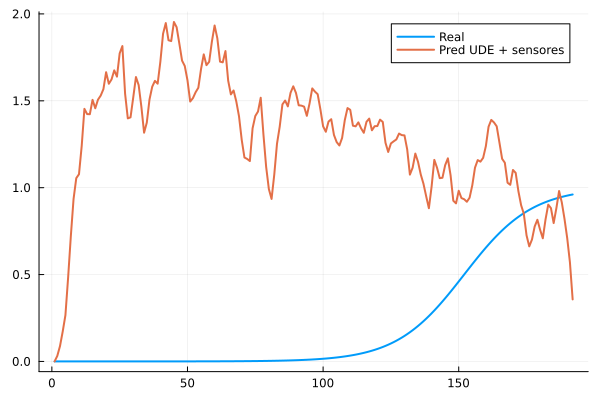

In [40]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2